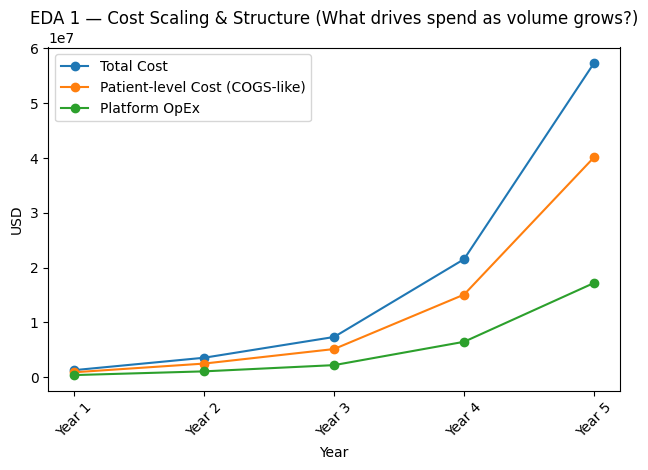

EDA 1 takeaway (manager): If Patient-level Cost dominates as volume grows, scalability depends on controlling pass-through costs, not just internal OpEx.


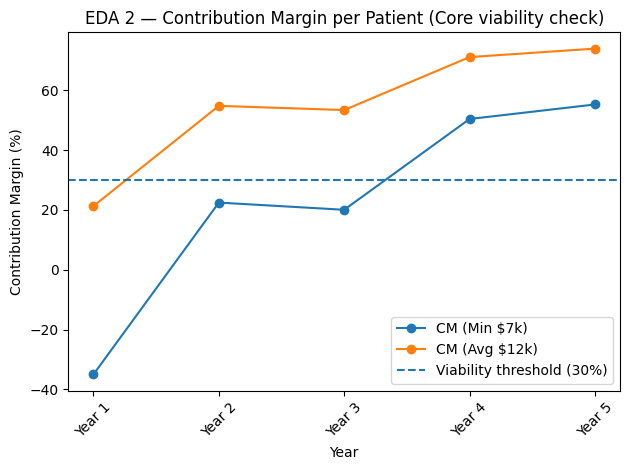

EDA 2 takeaway (manager): This is the headline KPI. If CM falls below 30% under conservative assumptions, the model is fragile.


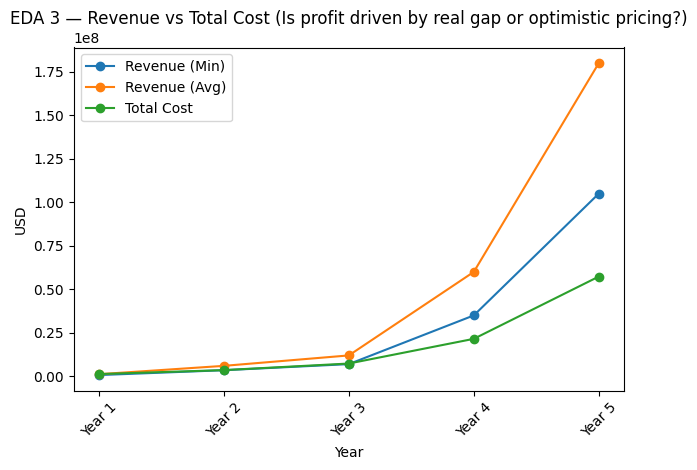

EDA 3 takeaway (manager): If Revenue lines are too close to Total Cost, profitability relies on optimistic assumptions and breaks under stress.


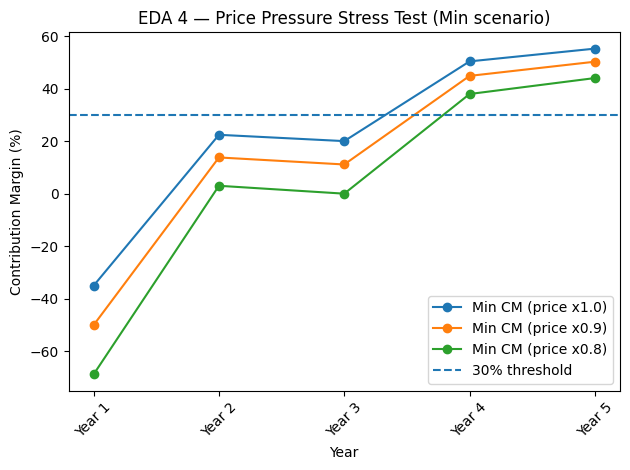

EDA 4 takeaway (manager): If CM collapses with a 10–20% price haircut, the model depends heavily on optimistic pricing assumptions.


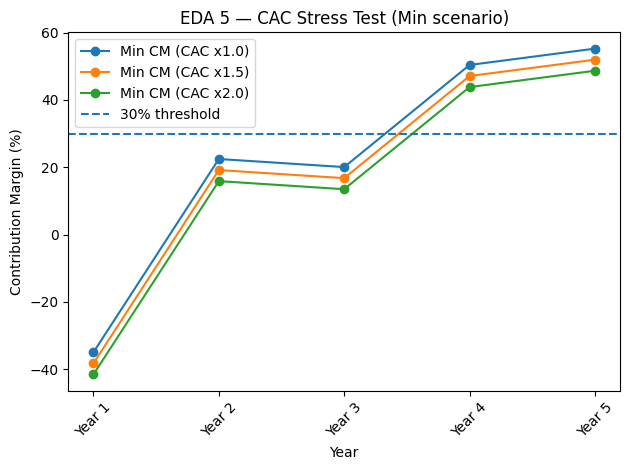

EDA 5 takeaway (manager): If CAC inflation pushes CM below threshold, growth is marketing-cost constrained, not demand constrained.


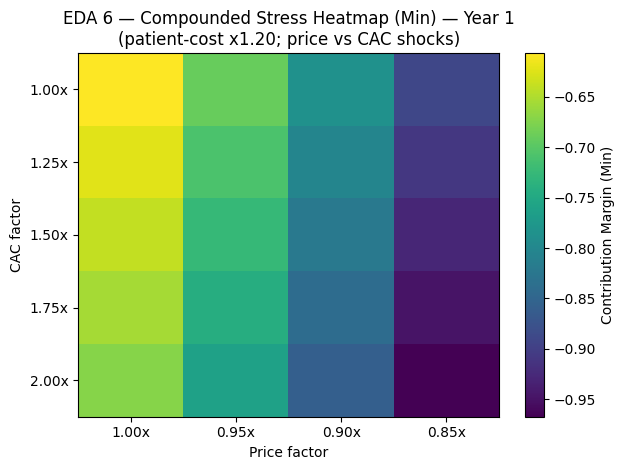

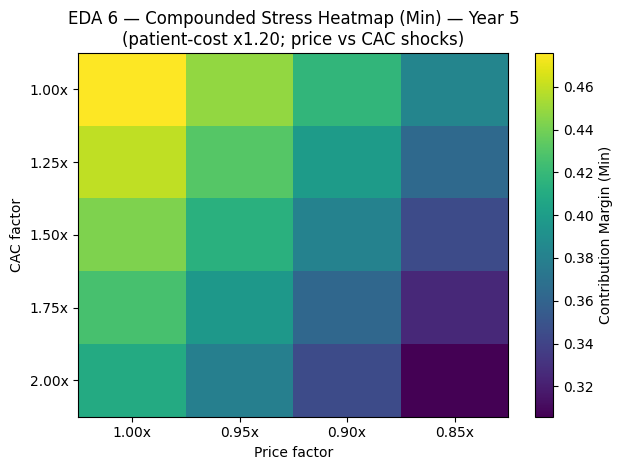

EDA 6 takeaway (manager): This shows viability boundaries under compounded stress. Cells below ~0.30 CM indicate the business model becomes non-viable under those combined conditions.

=== MANAGER SUMMARY (Base) ===
  Year  Patients  Revenue_Min  Total_Cost  Profit_Min    CM_Min  Revenue_Avg  Profit_Avg   CM_Avg
Year 1       100       700000     1284000     -584000 -0.349714      1200000      -84000 0.212667
Year 2       500      3500000     3550000      -50000  0.224286      6000000     2450000 0.547500
Year 3      1000      7000000     7340000     -340000  0.200286     12000000     4660000 0.533500
Year 4      5000     35000000    21535000    13465000  0.503586     60000000    38465000 0.710425
Year 5     15000    105000000    57325000    47675000  0.552119    180000000   122675000 0.738736

=== MANAGER SUMMARY (Compounded Conservative: price-10%, CAC+50%, patient costs+20%) ===
  Year  Patients  Revenue_Min(Comp)  Total_Cost(Comp)  Profit_Min(Comp)  CM_Min(Comp)
Year 1       100    

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 0) MANAGER-FACING ASSUMPTIONS (edit here only)
# ============================================================
YEARS = ["Year 1", "Year 2", "Year 3", "Year 4", "Year 5"]

# From sponsor screenshots (Revenue scaling)
PATIENTS = [100, 500, 1000, 5000, 15000]

# From sponsor screenshots (Total Operating Costs per year)
TOTAL_COST = [1284000, 3550000, 7340000, 21535000, 57325000]

# Sponsor pricing assumptions (unclear definition -> we treat as scenario levers)
REV_PER_PATIENT_MIN = 7000     # "Min 2 Implant"
REV_PER_PATIENT_AVG = 12000    # "Average 4 Implant"

# Sponsor CAC target assumption (also a scenario lever)
CAC_BASE = 460

# Cost structure split (since screenshots don’t give exact split):
# patient-level costs = treatment/flight/hotel (pass-through / COGS-like)
# platform OpEx = staffing/tech/legal/admin/marketing support etc.
PATIENT_COST_RATIO_BASE = 0.70   # manager-friendly starting point; adjust later if you extract exact split

# Sponsor success threshold for viability (from sponsor interview notes)
CM_THRESHOLD = 0.30


# ============================================================
# 1) BUILD CLEAN TABLES (no Excel read)
# ============================================================
df = pd.DataFrame({
    "Year": YEARS,
    "Patients": PATIENTS,
    "Total_Cost": TOTAL_COST,
})

# Split cost into Patient-level vs OpEx
df["Patient_Cost"] = df["Total_Cost"] * PATIENT_COST_RATIO_BASE
df["OpEx"] = df["Total_Cost"] - df["Patient_Cost"]

# Revenues (two scenarios)
df["Revenue_Min"] = df["Patients"] * REV_PER_PATIENT_MIN
df["Revenue_Avg"] = df["Patients"] * REV_PER_PATIENT_AVG

# Unit economics
df["Patient_Cost_per_Patient"] = df["Patient_Cost"] / df["Patients"]
df["OpEx_per_Patient"] = df["OpEx"] / df["Patients"]
df["CAC"] = CAC_BASE

# Contribution margin per patient (Manager KPI-friendly)
# Contribution margin = (revenue - patient costs - CAC) / revenue
df["CM_Min"] = (REV_PER_PATIENT_MIN - df["Patient_Cost_per_Patient"] - df["CAC"]) / REV_PER_PATIENT_MIN
df["CM_Avg"] = (REV_PER_PATIENT_AVG - df["Patient_Cost_per_Patient"] - df["CAC"]) / REV_PER_PATIENT_AVG

# Profit (coarse) = Revenue - Total Cost (note: cash-style, not formal accounting)
df["Profit_Min"] = df["Revenue_Min"] - df["Total_Cost"]
df["Profit_Avg"] = df["Revenue_Avg"] - df["Total_Cost"]

df


# ============================================================
# 2) MANAGER-READY VISUALS (6 charts)
#    Each chart answers one business question
# ============================================================

# ---------- Visual 1: Scaling & cost structure ----------
plt.figure()
plt.plot(df["Year"], df["Total_Cost"], marker="o", label="Total Cost")
plt.plot(df["Year"], df["Patient_Cost"], marker="o", label="Patient-level Cost (COGS-like)")
plt.plot(df["Year"], df["OpEx"], marker="o", label="Platform OpEx")
plt.title("EDA 1 — Cost Scaling & Structure (What drives spend as volume grows?)")
plt.xlabel("Year")
plt.ylabel("USD")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

print("EDA 1 takeaway (manager): If Patient-level Cost dominates as volume grows, scalability depends on controlling pass-through costs, not just internal OpEx.")


# ---------- Visual 2: Unit Economics — Contribution Margin ----------
plt.figure()
plt.plot(df["Year"], df["CM_Min"] * 100, marker="o", label="CM (Min $7k)")
plt.plot(df["Year"], df["CM_Avg"] * 100, marker="o", label="CM (Avg $12k)")
plt.axhline(CM_THRESHOLD * 100, linestyle="--", label="Viability threshold (30%)")
plt.title("EDA 2 — Contribution Margin per Patient (Core viability check)")
plt.xlabel("Year")
plt.ylabel("Contribution Margin (%)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

print("EDA 2 takeaway (manager): This is the headline KPI. If CM falls below 30% under conservative assumptions, the model is fragile.")


# ---------- Visual 3: Revenue vs Total Cost (gap view) ----------
plt.figure()
plt.plot(df["Year"], df["Revenue_Min"], marker="o", label="Revenue (Min)")
plt.plot(df["Year"], df["Revenue_Avg"], marker="o", label="Revenue (Avg)")
plt.plot(df["Year"], df["Total_Cost"], marker="o", label="Total Cost")
plt.title("EDA 3 — Revenue vs Total Cost (Is profit driven by real gap or optimistic pricing?)")
plt.xlabel("Year")
plt.ylabel("USD")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

print("EDA 3 takeaway (manager): If Revenue lines are too close to Total Cost, profitability relies on optimistic assumptions and breaks under stress.")


# ---------- Helper for scenario modeling ----------
def build_scenario(df_base, price_factor=1.0, cac_factor=1.0, patient_cost_factor=1.0):
    """
    price_factor: multiply revenue per patient (price pressure)
    cac_factor: multiply CAC (customer acquisition risk)
    patient_cost_factor: multiply patient-level costs (travel/medical cost inflation)
    """
    d = df_base.copy()

    # Apply scenario shocks to per-patient economics
    rev_min_s = REV_PER_PATIENT_MIN * price_factor
    rev_avg_s = REV_PER_PATIENT_AVG * price_factor
    cac_s = CAC_BASE * cac_factor

    # We apply patient cost inflation to patient-cost-per-patient
    pc_pp_s = d["Patient_Cost_per_Patient"] * patient_cost_factor

    d["Rev_Min_pp_S"] = rev_min_s
    d["Rev_Avg_pp_S"] = rev_avg_s
    d["CAC_S"] = cac_s
    d["Patient_Cost_pp_S"] = pc_pp_s

    d["CM_Min_S"] = (rev_min_s - pc_pp_s - cac_s) / rev_min_s
    d["CM_Avg_S"] = (rev_avg_s - pc_pp_s - cac_s) / rev_avg_s

    # Total-year scenario profits (cash-style)
    d["Revenue_Min_S"] = d["Patients"] * rev_min_s
    d["Revenue_Avg_S"] = d["Patients"] * rev_avg_s
    d["Total_Cost_S"] = (d["OpEx"] + d["Patient_Cost"] * patient_cost_factor)  # OpEx unchanged here; conservative could also step it
    d["Profit_Min_S"] = d["Revenue_Min_S"] - d["Total_Cost_S"]
    d["Profit_Avg_S"] = d["Revenue_Avg_S"] - d["Total_Cost_S"]

    d["Scenario_Label"] = f"price x{price_factor:.2f}, CAC x{cac_factor:.2f}, patient-cost x{patient_cost_factor:.2f}"
    return d


# ---------- Visual 4: Price-down stress test ----------
price_factors = [1.0, 0.9, 0.8]  # base, -10%, -20%
plt.figure()
for pf in price_factors:
    s = build_scenario(df, price_factor=pf, cac_factor=1.0, patient_cost_factor=1.0)
    plt.plot(s["Year"], s["CM_Min_S"] * 100, marker="o", label=f"Min CM (price x{pf})")
plt.axhline(CM_THRESHOLD * 100, linestyle="--", label="30% threshold")
plt.title("EDA 4 — Price Pressure Stress Test (Min scenario)")
plt.xlabel("Year")
plt.ylabel("Contribution Margin (%)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

print("EDA 4 takeaway (manager): If CM collapses with a 10–20% price haircut, the model depends heavily on optimistic pricing assumptions.")


# ---------- Visual 5: CAC stress test ----------
cac_factors = [1.0, 1.5, 2.0]  # base, +50%, +100%
plt.figure()
for cf in cac_factors:
    s = build_scenario(df, price_factor=1.0, cac_factor=cf, patient_cost_factor=1.0)
    plt.plot(s["Year"], s["CM_Min_S"] * 100, marker="o", label=f"Min CM (CAC x{cf})")
plt.axhline(CM_THRESHOLD * 100, linestyle="--", label="30% threshold")
plt.title("EDA 5 — CAC Stress Test (Min scenario)")
plt.xlabel("Year")
plt.ylabel("Contribution Margin (%)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

print("EDA 5 takeaway (manager): If CAC inflation pushes CM below threshold, growth is marketing-cost constrained, not demand constrained.")


# ---------- Visual 6: Compounded stress test heatmap ----------
# Compounded = price down + CAC up + patient costs up
price_grid = np.array([1.0, 0.95, 0.90, 0.85])
cac_grid = np.array([1.0, 1.25, 1.50, 1.75, 2.00])
patient_cost_factor = 1.20  # +20% (aligned with travel cost buffer idea)

# We'll compute CM for Year 1 and Year 5 (bookends) and show heatmaps
def heatmap_cm_for_year(year_label):
    row = df[df["Year"] == year_label].iloc[0]
    pc_pp_base = row["Patient_Cost_per_Patient"]

    mat = np.zeros((len(cac_grid), len(price_grid)))
    for i, cf in enumerate(cac_grid):
        for j, pf in enumerate(price_grid):
            rev = REV_PER_PATIENT_MIN * pf
            cac = CAC_BASE * cf
            pc_pp = pc_pp_base * patient_cost_factor
            mat[i, j] = (rev - pc_pp - cac) / rev
    return mat

for year_label in ["Year 1", "Year 5"]:
    mat = heatmap_cm_for_year(year_label)
    plt.figure()
    plt.imshow(mat, aspect="auto")
    plt.colorbar(label="Contribution Margin (Min)")
    plt.title(f"EDA 6 — Compounded Stress Heatmap (Min) — {year_label}\n"
              f"(patient-cost x{patient_cost_factor:.2f}; price vs CAC shocks)")
    plt.xticks(range(len(price_grid)), [f"{p:.2f}x" for p in price_grid])
    plt.yticks(range(len(cac_grid)), [f"{c:.2f}x" for c in cac_grid])
    plt.xlabel("Price factor")
    plt.ylabel("CAC factor")
    plt.tight_layout()
    plt.show()

print("EDA 6 takeaway (manager): This shows viability boundaries under compounded stress. "
      "Cells below ~0.30 CM indicate the business model becomes non-viable under those combined conditions.")


# ============================================================
# 3) SIMPLE MANAGER SUMMARY TABLE (base + 1 compounded scenario)
# ============================================================
scenario_compounded = build_scenario(df, price_factor=0.90, cac_factor=1.50, patient_cost_factor=1.20)

summary = df[["Year","Patients","Revenue_Min","Total_Cost","Profit_Min","CM_Min","Revenue_Avg","Profit_Avg","CM_Avg"]].copy()
summary.columns = ["Year","Patients","Revenue_Min","Total_Cost","Profit_Min","CM_Min",
                   "Revenue_Avg","Profit_Avg","CM_Avg"]

summary_comp = scenario_compounded[["Year","Patients","Revenue_Min_S","Total_Cost_S","Profit_Min_S","CM_Min_S"]].copy()
summary_comp.columns = ["Year","Patients","Revenue_Min(Comp)","Total_Cost(Comp)","Profit_Min(Comp)","CM_Min(Comp)"]

print("\n=== MANAGER SUMMARY (Base) ===")
print(summary.to_string(index=False))

print("\n=== MANAGER SUMMARY (Compounded Conservative: price-10%, CAC+50%, patient costs+20%) ===")
print(summary_comp.to_string(index=False))


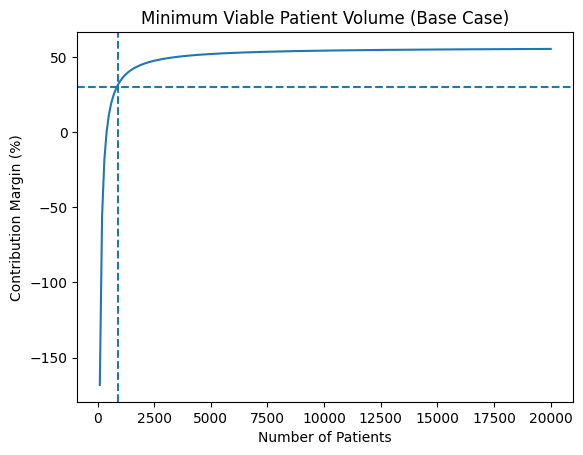


Minimum viable patient volume (CM ≥ 30%): ~900 patients


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# ----------------------------
# 1️⃣ 你的原始数据
# ----------------------------
patients = np.array([100, 500, 1000, 5000, 15000]).reshape(-1,1)
total_cost = np.array([1284000, 3550000, 7340000, 21535000, 57325000])

REV_PER_PATIENT = 7000
CAC = 460
PATIENT_COST_RATIO = 0.70
CM_THRESHOLD = 0.30

# ----------------------------
# 2️⃣ 拟合 Total Cost 函数
# ----------------------------
model = LinearRegression()
model.fit(patients, total_cost)

def total_cost_function(x):
    return model.predict(np.array(x).reshape(-1,1))

# ----------------------------
# 3️⃣ 构建连续规模区间
# ----------------------------
patient_range = np.linspace(100, 20000, 200)

total_cost_est = total_cost_function(patient_range)

patient_cost = total_cost_est * PATIENT_COST_RATIO
patient_cost_per_patient = patient_cost / patient_range

CM = (REV_PER_PATIENT - patient_cost_per_patient - CAC) / REV_PER_PATIENT

# ----------------------------
# 4️⃣ 找到最小 viable patient 数
# ----------------------------
viable_index = np.where(CM >= CM_THRESHOLD)[0][0]
min_viable_patients = patient_range[viable_index]

# ----------------------------
# 5️⃣ 作图
# ----------------------------
plt.figure()
plt.plot(patient_range, CM * 100)
plt.axhline(CM_THRESHOLD * 100, linestyle="--")
plt.axvline(min_viable_patients, linestyle="--")

plt.title("Minimum Viable Patient Volume (Base Case)")
plt.xlabel("Number of Patients")
plt.ylabel("Contribution Margin (%)")
plt.show()

print(f"\nMinimum viable patient volume (CM ≥ 30%): ~{int(min_viable_patients)} patients")
